<div style="width: 100%; clear: both;">
  <div style="float: left; width: 50%">
    <img src="https://www.ucc.edu.co/institucional/acerca-de-la-universidad/Documents/logo_ucc_2018(CURVAS)-01.png" align="left" style="max-width: 100%; height: auto;">
  </div>
  <div style="float: right; width: 50%;">
    <p style="margin: 0; padding-top: 22px; text-align:right;"><strong>Laboratorio de Tecnologias Emergentes</strong></p>
    <p style="margin: 0; text-align:right;"><strong>Linea de Inteligencia Artificial</strong></p>
    <p style="margin: 0; text-align:right;">Universidad Cooperativa de Colombia, Campus Ibague-Espinal</p>
    <p style="margin: 0; text-align:right;">Facultad de Ingenieria</p>
    <p style="margin: 0; text-align:right; padding-bottom: 100px;">Programa de Ingenieria de Sistemas</p>
  </div>
</div>
<div style="width:100%;">&nbsp;</div>
<div style="font-size: 20px; font-weight: bold; background: linear-gradient(to right, #ff7e5f, #feb47b); -webkit-background-clip: text; color: grey; text-align: center">W&F BirdLab -- 02 Preprocessing, Cropping & Metadata (v2)</div>

# 02 -- Preprocessing, YOLO Cropping & Metadata

Pipeline completo de preprocesamiento con clasificacion en **tres estados** y subcarpetas por motivo.

### Logica de clasificacion

```
imagen raw
    |
    v
[YOLO] -- sin deteccion ------------> REJECTED/no_detection/
    |
    v
[Umbrales DUROS]
    conf < 0.30  ───────────────────> REJECTED/low_confidence/
    area < 0.02  ───────────────────> REJECTED/small_area/
    bbox vacio tras clip ───────────> REJECTED/bbox_empty_after_clip/
    error de carga ─────────────────> REJECTED/load_error/
    |
    v
[Umbrales BLANDOS] -- alguno falla --> NEEDS_REVIEW/ (subcarpeta por flag)
    soft_low_confidence ────────────> review/low_confidence/<clase>/
    soft_small_bbox ────────────────> review/small_area/<clase>/
    touches_image_edge ─────────────> review/touches_edge/<clase>/
    aspect_ratio_out_of_range ──────> review/aspect_ratio/<clase>/
    bbox_required_clipping ─────────> review/clipped/<clase>/
    final_image_too_small ──────────> review/final_too_small/<clase>/
    (multiple flags: carpeta del primer flag)
    |
    v
ACCEPTED → data/processed/<clase>/
```

### Estructura de carpetas

```
data/
├── processed/
│   └── <clase>/          ← ACCEPTED
├── review/
│   ├── low_confidence/
│   │   └── <clase>/
│   ├── small_area/
│   │   └── <clase>/
│   ├── touches_edge/
│   │   └── <clase>/
│   ├── aspect_ratio/
│   │   └── <clase>/
│   ├── clipped/
│   │   └── <clase>/
│   └── final_too_small/
│       └── <clase>/
└── rejected/
    ├── no_detection/
    │   └── <clase>/
    ├── low_confidence/
    │   └── <clase>/
    ├── small_area/
    │   └── <clase>/
    ├── bbox_empty_after_clip/
    │   └── <clase>/
    └── load_error/
        └── <clase>/
```

## 1. Entorno y configuracion

In [2]:
import sys
import shutil
from pathlib import Path
from collections import defaultdict, Counter
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "dataset.yaml"

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

print("Configuracion:")
for k, v in config.items():
    print(f"  {k:<28} {v}")

Configuracion:
  raw_data_path                data/raw
  processed_data_path          data/processed
  split_ratio                  [0.75, 0.15, 0.1]
  image_size                   224
  min_confidence               0.5
  min_bbox_area_ratio          0.05
  margin_ratio                 0.2
  hard_min_confidence          0.3
  hard_min_bbox_area_ratio     0.02
  soft_min_confidence          0.6
  soft_min_bbox_area_ratio     0.08
  min_aspect_ratio             0.5
  max_aspect_ratio             2.0


## 2. Mapeos de subcarpetas

In [2]:
# ── Mapeo: rejection_reason  →  subcarpeta dentro de data/rejected/ ──
REJECTION_SUBDIR = {
    "no_detection":          "no_detection",
    "hard_low_confidence":   "low_confidence",
    "hard_small_bbox":       "small_area",
    "bbox_empty_after_clip": "bbox_empty_after_clip",
    "load_error":            "load_error",
}

# ── Mapeo: review_flag (primer flag)  →  subcarpeta dentro de data/review/ ──
REVIEW_FLAG_SUBDIR = {
    "soft_low_confidence":       "low_confidence",
    "soft_small_bbox":           "small_area",
    "touches_image_edge":        "touches_edge",
    "aspect_ratio_out_of_range": "aspect_ratio",
    "bbox_required_clipping":    "clipped",
    "final_image_too_small":     "final_too_small",
}

# Etiquetas legibles para graficas
REJECTION_LABELS = {
    "no_detection":          "Sin deteccion YOLO",
    "low_confidence":        "Confianza baja (duro)",
    "small_area":            "Area pequeña (duro)",
    "bbox_empty_after_clip": "Bbox vacio tras clip",
    "load_error":            "Error al cargar imagen",
}

FLAG_LABELS = {
    "soft_low_confidence":       "Confianza baja (soft)",
    "soft_small_bbox":           "Area pequeña (soft)",
    "touches_image_edge":        "Toca borde imagen",
    "aspect_ratio_out_of_range": "Aspect ratio fuera de rango",
    "bbox_required_clipping":    "Requirio clipping",
    "final_image_too_small":     "Imagen final muy pequeña",
}

print("Subcarpetas de rechazo:")
for k, v in REJECTION_SUBDIR.items():
    print(f"  {k:<30} → rejected/{v}/")

print()
print("Subcarpetas de review:")
for k, v in REVIEW_FLAG_SUBDIR.items():
    print(f"  {k:<30} → review/{v}/")

Subcarpetas de rechazo:
  no_detection                   → rejected/no_detection/
  hard_low_confidence            → rejected/low_confidence/
  hard_small_bbox                → rejected/small_area/
  bbox_empty_after_clip          → rejected/bbox_empty_after_clip/
  load_error                     → rejected/load_error/

Subcarpetas de review:
  soft_low_confidence            → review/low_confidence/
  soft_small_bbox                → review/small_area/
  touches_image_edge             → review/touches_edge/
  aspect_ratio_out_of_range      → review/aspect_ratio/
  bbox_required_clipping         → review/clipped/
  final_image_too_small          → review/final_too_small/


## 3. Inicializar BirdCropper y MetadataDB

In [3]:
from src.utils.cropping  import BirdCropper, ImageStatus, RejectionReason, process_class_directory
from src.utils.metadata  import MetadataDB

# ── Cropper ─────────────────────────────────────────────────────
cropper = BirdCropper.from_config(str(CONFIG_PATH))
_ = cropper.model   # forzar carga YOLO aqui
print("Modelo YOLO listo.")

# ── Base de datos ────────────────────────────────────────────────
DB_PATH = PROJECT_ROOT / "metadata" / "metadata.sqlite"
db = MetadataDB(DB_PATH)
print(f"MetadataDB: {DB_PATH}")
print(f"Registros existentes: {db.count()}")

Modelo YOLO listo.
MetadataDB: D:\desarrollo\bird-lab\metadata\metadata.sqlite
Registros existentes: 11586


## 4. Umbrales del pipeline

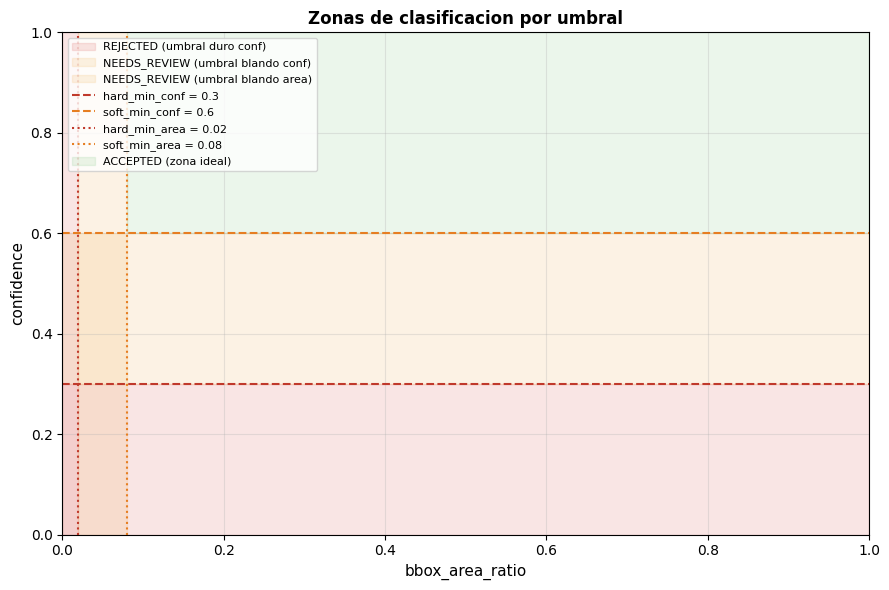

In [4]:
cfg = cropper.cfg

fig, ax = plt.subplots(figsize=(9, 6))

ax.axhspan(0,              cfg.hard_min_confidence,      xmin=0, xmax=1,
           color="#d9534f", alpha=0.15, label="REJECTED (umbral duro conf)")
ax.axhspan(cfg.hard_min_confidence, cfg.soft_min_confidence, xmin=0, xmax=1,
           color="#f0ad4e", alpha=0.15, label="NEEDS_REVIEW (umbral blando conf)")

ax.axvspan(0,              cfg.hard_min_bbox_area_ratio, ymin=0, ymax=1,
           color="#d9534f", alpha=0.15)
ax.axvspan(cfg.hard_min_bbox_area_ratio, cfg.soft_min_bbox_area_ratio, ymin=0, ymax=1,
           color="#f0ad4e", alpha=0.15, label="NEEDS_REVIEW (umbral blando area)")

ax.axhline(cfg.hard_min_confidence, color="#c0392b", lw=1.5, ls="--",
           label=f"hard_min_conf = {cfg.hard_min_confidence}")
ax.axhline(cfg.soft_min_confidence, color="#e67e22", lw=1.5, ls="--",
           label=f"soft_min_conf = {cfg.soft_min_confidence}")
ax.axvline(cfg.hard_min_bbox_area_ratio, color="#c0392b", lw=1.5, ls=":",
           label=f"hard_min_area = {cfg.hard_min_bbox_area_ratio}")
ax.axvline(cfg.soft_min_bbox_area_ratio, color="#e67e22", lw=1.5, ls=":",
           label=f"soft_min_area = {cfg.soft_min_bbox_area_ratio}")

ax.fill_between(
    [cfg.soft_min_bbox_area_ratio, 1.0],
    [cfg.soft_min_confidence,       cfg.soft_min_confidence],
    [1.0,                            1.0],
    color="#5cb85c", alpha=0.12, label="ACCEPTED (zona ideal)"
)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("bbox_area_ratio", fontsize=11)
ax.set_ylabel("confidence", fontsize=11)
ax.set_title("Zonas de clasificacion por umbral", fontweight="bold", fontsize=12)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "logs" / "02_thresholds.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Prueba unitaria -- una imagen

In [5]:
RAW_DIR = PROJECT_ROOT / config["raw_data_path"]

sample_path = next(
    (f for cls_dir in sorted(RAW_DIR.iterdir()) if cls_dir.is_dir()
     for f in sorted(cls_dir.iterdir())
     if f.suffix.lower() in {".jpg", ".jpeg", ".png"}),
    None
)

if sample_path is None:
    print("No se encontraron imagenes en data/raw/.")
else:
    result = cropper.crop(sample_path)
    m      = result.metrics

    print(f"Imagen  : {sample_path.relative_to(PROJECT_ROOT)}")
    print(f"Estado  : {result.status.upper()}")
    if m:
        print(f"  confidence      : {m.confidence:.4f}")
        print(f"  bbox_area_ratio : {m.bbox_area_ratio:.4f}")
        print(f"  touches_edge    : {m.touches_edge}")
        print(f"  clipped         : {m.clipped}")
        print(f"  aspect_ratio    : {m.aspect_ratio:.4f}")
        print(f"  final_size      : {m.final_w}x{m.final_h}")
    if result.rejected:
        print(f"  rejection_reason: {result.rejection_reason}")
    if result.needs_review:
        print(f"  review_flags    : {result.review_flags}")
    print()
    import json
    print(json.dumps(result.to_metadata_dict(), indent=2, default=str))

Imagen  : data\raw\ardea-alba\ardea-alba_0013c9efa6.jpg
Estado  : NEEDS_REVIEW
  confidence      : 0.8259
  bbox_area_ratio : 0.0797
  touches_edge    : False
  clipped         : False
  aspect_ratio    : 0.9869
  final_size      : 224x224
  review_flags    : ['soft_small_bbox']

{
  "image": "ardea-alba_0013c9efa6.jpg",
  "class": "ardea-alba",
  "status": "needs_review",
  "confidence": 0.8259,
  "bbox_area_ratio": 0.0797,
  "touches_edge": false,
  "clipped": false,
  "aspect_ratio": 0.9869,
  "final_w": 224,
  "final_h": 224,
  "rejection_reason": null,
  "review_flags": "soft_small_bbox"
}


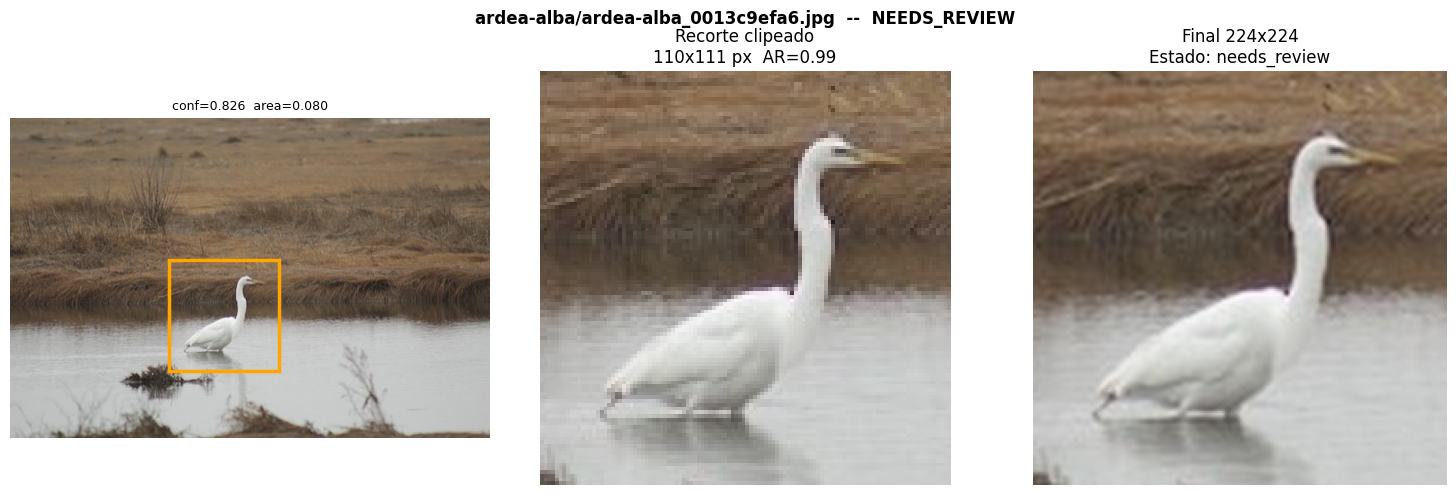

In [6]:
# Visualizacion del bbox sobre la imagen original
if sample_path and result.metrics and result.metrics.bbox_clipped:
    img_orig = Image.open(sample_path).convert("RGB")
    W, H = img_orig.size
    m = result.metrics

    STATUS_COLOR = {
        ImageStatus.ACCEPTED:     "limegreen",
        ImageStatus.NEEDS_REVIEW: "orange",
        ImageStatus.REJECTED:     "red",
    }
    color = STATUS_COLOR.get(result.status, "gray")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f"{sample_path.parent.name}/{sample_path.name}  --  {result.status.upper()}",
        fontsize=12, fontweight="bold"
    )

    ax = axes[0]
    ax.imshow(img_orig)
    if m.bbox_clipped:
        x1,y1,x2,y2 = [int(v) for v in m.bbox_clipped]
        rect = plt.Rectangle((x1,y1), x2-x1, y2-y1,
                              edgecolor=color, facecolor="none", lw=2.5)
        ax.add_patch(rect)
    title_lines = [f"conf={m.confidence:.3f}  area={m.bbox_area_ratio:.3f}"]
    if m.touches_edge: title_lines.append("toca borde")
    if m.clipped:      title_lines.append("clipeado")
    ax.set_title("\n".join(title_lines), fontsize=9)
    ax.axis("off")

    ax = axes[1]
    if m.bbox_clipped:
        x1,y1,x2,y2 = [int(v) for v in m.bbox_clipped]
        patch = img_orig.crop((x1,y1,x2,y2))
        ax.imshow(patch)
        ax.set_title(f"Recorte clipeado\n{patch.size[0]}x{patch.size[1]} px  AR={m.aspect_ratio:.2f}")
    ax.axis("off")

    ax = axes[2]
    if result.image:
        ax.imshow(result.image)
        ax.set_title(f"Final {m.final_w}x{m.final_h}\nEstado: {result.status}")
    else:
        ax.text(0.5, 0.5, "RECHAZADA\nsin imagen", ha="center", va="center",
                fontsize=12, color="red", transform=ax.transAxes)
    ax.axis("off")

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "logs" / "02_sample_pipeline.png", dpi=150, bbox_inches="tight")
    plt.show()

## 6. Procesar el dataset completo

Separa imagenes en subcarpetas por motivo dentro de `review/` y `rejected/`.
Las imagenes **rejected** se copian en su subcarpeta (originales sin procesar).
Las imagenes **review** se copian procesadas (recortadas) en su subcarpeta.

In [10]:
PROCESSED_DIR = PROJECT_ROOT / config["processed_data_path"]
REVIEW_DIR    = PROJECT_ROOT / "data" / "review"
REJECTED_DIR  = PROJECT_ROOT / "data" / "rejected"

# Limpiar DB
db.clear()
print("Base de datos limpiada.")

class_dirs = sorted(d for d in RAW_DIR.iterdir() if d.is_dir())
print(f"Clases a procesar: {len(class_dirs)}")
print()

# ── Helpers para resolver subcarpetas ───────────────────────────────────────

def get_review_subdir(result) -> str:
    """Primer flag → nombre de subcarpeta en review/."""
    flags = result.review_flags or []
    first_flag = flags[0].strip() if flags else ""
    return REVIEW_FLAG_SUBDIR.get(first_flag, "other")

def get_rejected_subdir(result) -> str:
    """rejection_reason → nombre de subcarpeta en rejected/."""
    reason = result.rejection_reason or "unknown"
    return REJECTION_SUBDIR.get(reason, "other")

def save_image_pil(pil_image, dest_path: Path):
    """Guarda imagen PIL en dest_path creando directorios si hacen falta."""
    dest_path.parent.mkdir(parents=True, exist_ok=True)
    pil_image.save(dest_path)

def copy_original(src_path: Path, dest_path: Path):
    """Copia imagen original (sin procesar) a dest_path."""
    dest_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src_path, dest_path)

# ── Procesar ─────────────────────────────────────────────────────────────────

all_results = []

print(f"{'Clase':<32} {'Acc':>5} {'Rev':>5} {'Rej':>5} {'Tot':>5}  Tasa OK")
print("-" * 65)

for cls_dir in class_dirs:
    cls_name = cls_dir.name
    n_acc = n_rev = n_rej = 0

    images = [f for f in sorted(cls_dir.iterdir())
              if f.suffix.lower() in {".jpg", ".jpeg", ".png"}]

    for img_path in images:
        result = cropper.crop(img_path)

        if result.accepted:
            # ── ACCEPTED: imagen procesada en processed/<clase>/ ──────────
            dest = PROCESSED_DIR / cls_name / img_path.name
            dest.parent.mkdir(parents=True, exist_ok=True)
            result.image.save(dest)
            n_acc += 1

        elif result.needs_review:
            # ── NEEDS_REVIEW: imagen procesada en review/<motivo>/<clase>/ ─
            subdir = get_review_subdir(result)
            dest   = REVIEW_DIR / subdir / cls_name / img_path.name
            if result.image is not None:
                save_image_pil(result.image, dest)
            else:
                # Si no hay imagen procesada, copiar original
                copy_original(img_path, dest)
            n_rev += 1

        else:  # rejected
            # ── REJECTED: original en rejected/<motivo>/<clase>/ ───────────
            subdir = get_rejected_subdir(result)
            dest   = REJECTED_DIR / subdir / cls_name / img_path.name
            copy_original(img_path, dest)
            n_rej += 1

        meta = result.to_metadata_dict()
        all_results.append((result, meta))

    # Guardar metadata en batch por clase
    records = [m for _, m in all_results[-len(images):]]
    db.insert_batch(records)

    tot = len(images)
    pct = (n_acc + n_rev) / tot * 100 if tot else 0
    print(f"{cls_name:<32} {n_acc:>5} {n_rev:>5} {n_rej:>5} {tot:>5}  {pct:.0f}%")

print("-" * 65)
total_acc = sum(1 for r, _ in all_results if r.accepted)
total_rev = sum(1 for r, _ in all_results if r.needs_review)
total_rej = sum(1 for r, _ in all_results if r.rejected)
total_all = len(all_results)
print(f"{'TOTAL':<32} {total_acc:>5} {total_rev:>5} {total_rej:>5} {total_all:>5}")
print(f"\nRegistros en DB: {db.count()}")

Base de datos limpiada.
Clases a procesar: 16

Clase                              Acc   Rev   Rej   Tot  Tasa OK
-----------------------------------------------------------------
ardea-alba                         251   377   182   810  78%
atlapetes-latinuchus               170   279    88   537  84%
butorides-striata                  220   248    70   538  87%
chlorochrysa-nitidissima           292   332    60   684  91%
colibri-coruscans                  198   408   107   713  85%
gallinula-galeata                  230   320   199   749  73%
metallura-tyrianthina              219   302   108   629  83%
momotus-aequatorialis              204   558    75   837  91%
phimosus-infuscatus                280   359   164   803  80%
piaya-cayana                       105   336   188   629  70%
pitangus-sulphuratus               271   329   118   718  84%
ramphastos-ambiguus                204   455   382  1041  63%
sicalis-flaveola                   283   341   154   778  80%
thraupis-episco

## 7. Verificacion de estructura de carpetas generada

In [13]:
PROCESSED_DIR = PROJECT_ROOT / config["processed_data_path"]
REVIEW_DIR    = PROJECT_ROOT / "data" / "review"
REJECTED_DIR  = PROJECT_ROOT / "data" / "rejected"
def count_images_in_dir(base_dir: Path, exts={".jpg", ".jpeg", ".png"}) -> dict:
    """Cuenta imagenes por subcarpeta recursivamente."""
    counts = {}
    if not base_dir.exists():
        return counts
    for subdir in sorted(base_dir.rglob("*")):
        if subdir.is_dir():
            n = sum(1 for f in subdir.iterdir() if f.suffix.lower() in exts)
            if n > 0:
                rel = subdir.relative_to(base_dir)
                counts[str(rel)] = n
    return counts

print("=" * 55)
print("  data/processed/ (ACCEPTED)")
print("=" * 55)
proc_counts = count_images_in_dir(PROCESSED_DIR)
for k, v in proc_counts.items():
    print(f"  {k:<40} {v:>5} imgs")
print(f"  TOTAL: {sum(proc_counts.values())}")

print()
print("=" * 55)
print("  data/review/ (NEEDS_REVIEW por motivo)")
print("=" * 55)
rev_counts = count_images_in_dir(REVIEW_DIR)
for k, v in rev_counts.items():
    print(f"  {k:<40} {v:>5} imgs")
print(f"  TOTAL: {sum(rev_counts.values())}")

print()
print("=" * 55)
print("  data/rejected/ (REJECTED por motivo, originales)")
print("=" * 55)
rej_counts = count_images_in_dir(REJECTED_DIR)
for k, v in rej_counts.items():
    print(f"  {k:<40} {v:>5} imgs")
print(f"  TOTAL: {sum(rej_counts.values())}")

  data/processed/ (ACCEPTED)
  ardea-alba                                 569 imgs
  atlapetes-latinuchus                       446 imgs
  butorides-striata                          463 imgs
  chlorochrysa-nitidissima                   558 imgs
  colibri-coruscans                          499 imgs
  gallinula-galeata                          545 imgs
  metallura-tyrianthina                      408 imgs
  momotus-aequatorialis                      692 imgs
  phimosus-infuscatus                        577 imgs
  piaya-cayana                               433 imgs
  pitangus-sulphuratus                       583 imgs
  ramphastos-ambiguus                        647 imgs
  sicalis-flaveola                           578 imgs
  thraupis-episcopus                         444 imgs
  turdus-fuscater                            683 imgs
  zenaida-auriculata                         557 imgs
  TOTAL: 8682

  data/review/ (NEEDS_REVIEW por motivo)
  aspect_ratio\momotus-aequatorialis          48 im

## 8. Resumen estadistico desde la base de datos

In [12]:
summary = db.summary()

print(f"Total imagenes procesadas : {summary['total']}")
print()
print("Por estado:")
for status, n in sorted(summary["by_status"].items()):
    pct = n / summary["total"] * 100 if summary["total"] else 0
    bar = "#" * int(pct / 2)
    print(f"  {status:<14} {n:>5}  ({pct:5.1f}%)  {bar}")

print()
print(f"Confianza media         : {summary['avg_confidence']:.4f}")
print(f"Area bbox media         : {summary['avg_bbox_area_ratio']:.4f}")

Total imagenes procesadas : 11586

Por estado:
  accepted        3720  ( 32.1%)  ################
  needs_review    5658  ( 48.8%)  ########################
  rejected        2208  ( 19.1%)  #########

Confianza media         : 0.7550
Area bbox media         : 0.3645


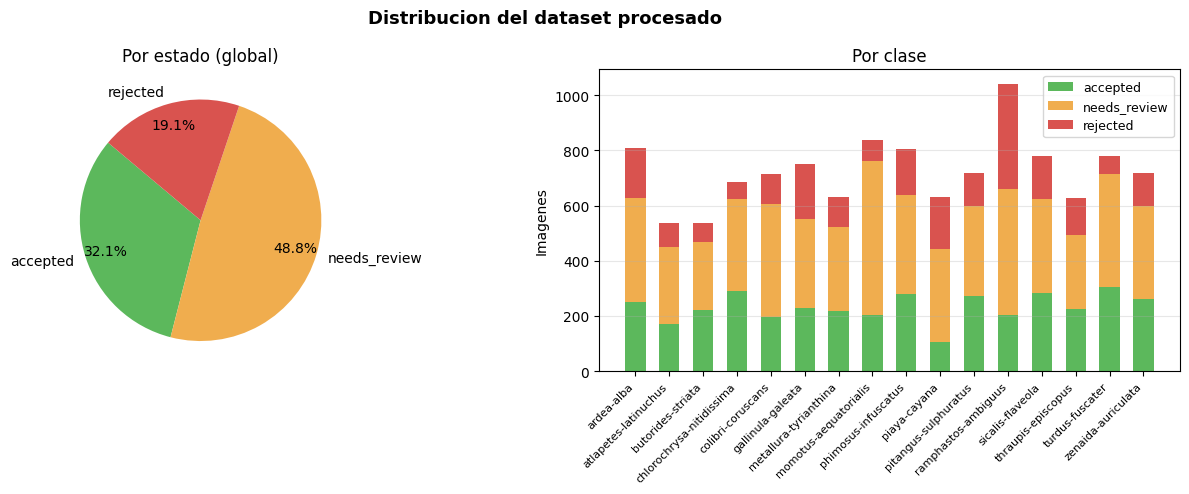

In [13]:
status_data = summary["by_status"]
labels  = list(status_data.keys())
values  = list(status_data.values())
palette = {"accepted": "#5cb85c", "needs_review": "#f0ad4e", "rejected": "#d9534f"}
colors  = [palette.get(l, "#aaaaaa") for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Distribucion del dataset procesado", fontsize=13, fontweight="bold")

axes[0].pie(values, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=140, pctdistance=0.82)
axes[0].set_title("Por estado (global)")

classes_sorted = sorted(summary["by_class"].keys())
acc_vals  = [summary["by_class"][c].get("accepted",     0) for c in classes_sorted]
rev_vals  = [summary["by_class"][c].get("needs_review", 0) for c in classes_sorted]
rej_vals  = [summary["by_class"][c].get("rejected",     0) for c in classes_sorted]

x = np.arange(len(classes_sorted))
w = 0.6
axes[1].bar(x, acc_vals,  w, label="accepted",     color="#5cb85c")
axes[1].bar(x, rev_vals,  w, label="needs_review", color="#f0ad4e", bottom=acc_vals)
axes[1].bar(x, rej_vals,  w, label="rejected",     color="#d9534f",
            bottom=[a+r for a,r in zip(acc_vals, rev_vals)])
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes_sorted, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Imagenes")
axes[1].set_title("Por clase")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "logs" / "02_status_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 9. Analisis de flags de needs_review

In [14]:
flag_counts = summary["review_flag_counts"]
if not flag_counts:
    print("No hay imagenes en needs_review.")
else:
    sorted_flags = sorted(flag_counts.items(), key=lambda x: x[1], reverse=True)
    labels_f = [FLAG_LABELS.get(k, k) for k, _ in sorted_flags]
    values_f = [v for _, v in sorted_flags]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(labels_f[::-1], values_f[::-1], color="#f0ad4e")
    for bar, val in zip(bars, values_f[::-1]):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                str(val), va="center", fontsize=9)
    ax.set_xlabel("Numero de imagenes con este flag")
    ax.set_title("Frecuencia de flags en NEEDS_REVIEW", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "logs" / "02_review_flags.png", dpi=150, bbox_inches="tight")
    plt.show()

    total_review = summary["by_status"].get("needs_review", 0)
    print(f"Total imagenes en needs_review: {total_review}")
    for k, v in sorted_flags:
        label = FLAG_LABELS.get(k, k)
        pct   = v / total_review * 100 if total_review else 0
        subdir = REVIEW_FLAG_SUBDIR.get(k, "other")
        print(f"  {label:<38} {v:>5}  ({pct:.1f}%)  → review/{subdir}/")

NameError: name 'summary' is not defined

## 10. Galeria de imagenes rechazadas por subcarpeta

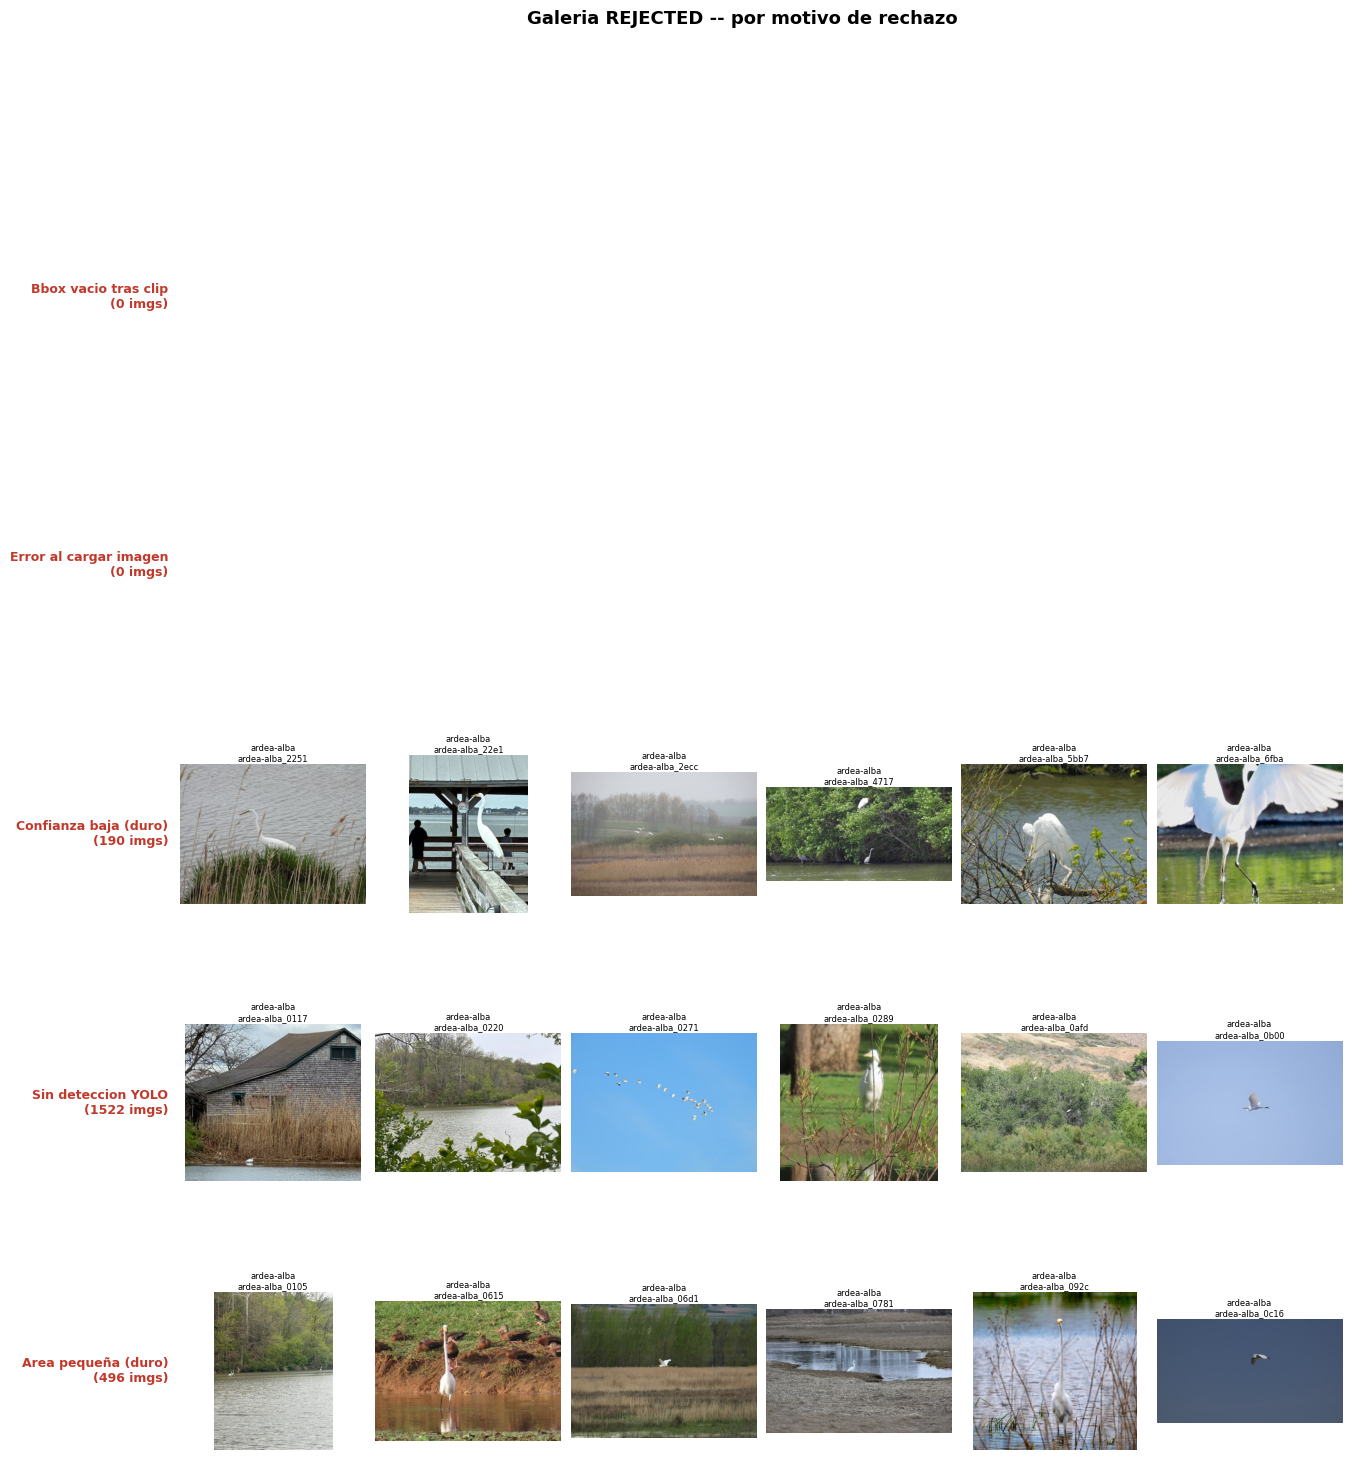

In [15]:
def show_rejected_gallery(rejected_base: Path, max_per_group: int = 6, save_name: str = None):
    """
    Galeria de REJECTED agrupada por subcarpeta (motivo).
    Las imagenes se toman directamente de data/rejected/<motivo>/<clase>/
    """
    subdirs = sorted([d for d in rejected_base.iterdir() if d.is_dir()])
    if not subdirs:
        print("Sin imagenes rechazadas.")
        return

    fig = plt.figure(figsize=(max_per_group * 2.5, len(subdirs) * 3.2))
    fig.suptitle("Galeria REJECTED -- por motivo de rechazo",
                 fontsize=13, fontweight="bold", y=1.01)
    outer = gridspec.GridSpec(len(subdirs), 1, figure=fig, hspace=0.7)

    for row_idx, subdir in enumerate(subdirs):
        # Recopilar todas las imagenes en este motivo (todas las clases)
        all_imgs = [f for cls_d in sorted(subdir.iterdir()) if cls_d.is_dir()
                    for f in sorted(cls_d.iterdir())
                    if f.suffix.lower() in {".jpg", ".jpeg", ".png"}]
        sample = all_imgs[:max_per_group]
        label  = REJECTION_LABELS.get(subdir.name, subdir.name)

        inner = gridspec.GridSpecFromSubplotSpec(
            1, max_per_group, subplot_spec=outer[row_idx], wspace=0.05
        )
        ax_label = fig.add_subplot(outer[row_idx])
        ax_label.set_axis_off()
        ax_label.text(
            -0.01, 0.5,
            f"{label}\n({len(all_imgs)} imgs)",
            transform=ax_label.transAxes,
            va="center", ha="right", fontsize=9, fontweight="bold", color="#c0392b"
        )

        for col_idx in range(max_per_group):
            ax = fig.add_subplot(inner[col_idx])
            ax.set_axis_off()
            if col_idx >= len(sample):
                continue
            img_path = sample[col_idx]
            try:
                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
                ax.set_title(f"{img_path.parent.name[:15]}\n{img_path.name[:15]}",
                             fontsize=6, pad=2)
            except Exception:
                ax.text(0.5, 0.5, "N/D", ha="center", va="center",
                        fontsize=8, color="gray", transform=ax.transAxes)

    if save_name:
        plt.savefig(PROJECT_ROOT / "logs" / save_name, dpi=120, bbox_inches="tight")
    plt.show()


show_rejected_gallery(
    rejected_base = REJECTED_DIR,
    max_per_group = 6,
    save_name     = "02_rejected_gallery.png",
)

## 11. Galeria de imagenes NEEDS_REVIEW por subcarpeta

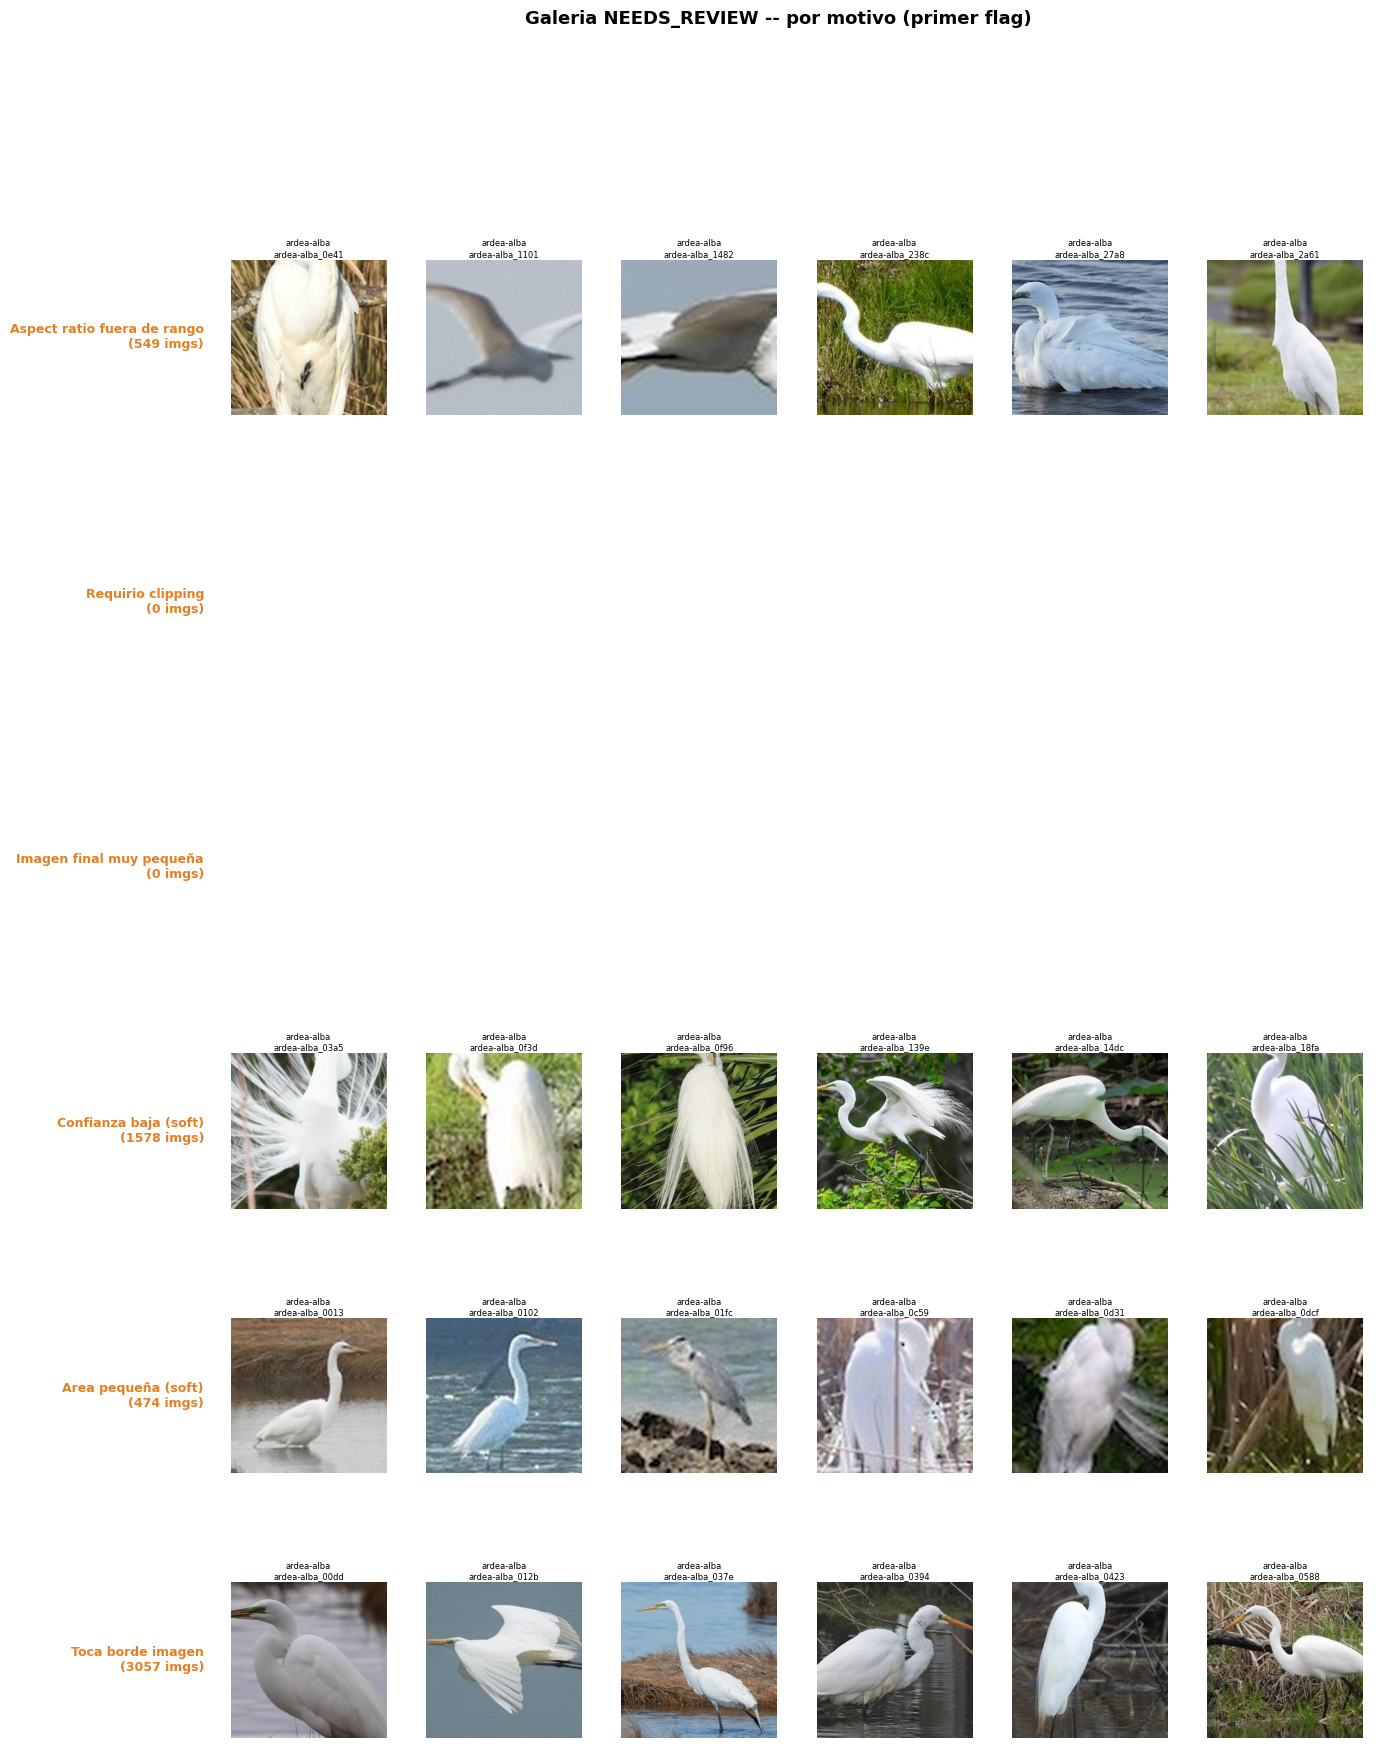

In [16]:
FLAG_LABELS_BY_SUBDIR = {
    "low_confidence":  "Confianza baja (soft)",
    "small_area":      "Area pequeña (soft)",
    "touches_edge":    "Toca borde imagen",
    "aspect_ratio":    "Aspect ratio fuera de rango",
    "clipped":         "Requirio clipping",
    "final_too_small": "Imagen final muy pequeña",
    "other":           "Otro motivo",
}

def show_review_gallery(review_base: Path, max_per_group: int = 6, save_name: str = None):
    """
    Galeria de NEEDS_REVIEW agrupada por subcarpeta (motivo del primer flag).
    """
    subdirs = sorted([d for d in review_base.iterdir() if d.is_dir()])
    if not subdirs:
        print("Sin imagenes en review.")
        return

    fig = plt.figure(figsize=(max_per_group * 2.5, len(subdirs) * 3.2))
    fig.suptitle("Galeria NEEDS_REVIEW -- por motivo (primer flag)",
                 fontsize=13, fontweight="bold", y=1.01)
    outer = gridspec.GridSpec(len(subdirs), 1, figure=fig, hspace=0.7)

    for row_idx, subdir in enumerate(subdirs):
        all_imgs = [f for cls_d in sorted(subdir.iterdir()) if cls_d.is_dir()
                    for f in sorted(cls_d.iterdir())
                    if f.suffix.lower() in {".jpg", ".jpeg", ".png"}]
        sample = all_imgs[:max_per_group]
        label  = FLAG_LABELS_BY_SUBDIR.get(subdir.name, subdir.name)

        inner = gridspec.GridSpecFromSubplotSpec(
            1, max_per_group, subplot_spec=outer[row_idx], wspace=0.05
        )
        ax_label = fig.add_subplot(outer[row_idx])
        ax_label.set_axis_off()
        ax_label.text(
            -0.01, 0.5,
            f"{label}\n({len(all_imgs)} imgs)",
            transform=ax_label.transAxes,
            va="center", ha="right", fontsize=9, fontweight="bold", color="#e67e22"
        )

        for col_idx in range(max_per_group):
            ax = fig.add_subplot(inner[col_idx])
            ax.set_axis_off()
            if col_idx >= len(sample):
                continue
            img_path = sample[col_idx]
            try:
                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
                ax.set_title(f"{img_path.parent.name[:15]}\n{img_path.name[:15]}",
                             fontsize=6, pad=2)
            except Exception:
                ax.text(0.5, 0.5, "N/D", ha="center", va="center",
                        fontsize=8, color="gray", transform=ax.transAxes)

    if save_name:
        plt.savefig(PROJECT_ROOT / "logs" / save_name, dpi=120, bbox_inches="tight")
    plt.show()


show_review_gallery(
    review_base   = REVIEW_DIR,
    max_per_group = 6,
    save_name     = "02_review_gallery.png",
)

## 12. Consultas de ejemplo sobre la DB

In [17]:
import json

# a) Imagenes que tocan borde Y tienen baja confianza
touching_low = db.query_by_flag("touches_image_edge")
touching_low_conf = [r for r in touching_low if (r["confidence"] or 1) < 0.55]
print(f"Imagenes que tocan borde con conf < 0.55: {len(touching_low_conf)}")
if touching_low_conf:
    print(json.dumps(touching_low_conf[0], indent=2, default=str))

print()

# b) Clase con mayor tasa de rechazo
by_class = summary["by_class"]
reject_rate = {
    cls: (data.get("rejected", 0) / sum(data.values()) * 100)
    for cls, data in by_class.items() if sum(data.values()) > 0
}
worst_class = max(reject_rate, key=reject_rate.get) if reject_rate else None
if worst_class:
    print(f"Clase con mayor tasa de rechazo: {worst_class} ({reject_rate[worst_class]:.1f}%)")
    print(f"  Detalle: {dict(by_class[worst_class])}")

Imagenes que tocan borde con conf < 0.55: 413
{
  "id": 20992,
  "image": "ardea-alba_03a5582af5.jpg",
  "class": "ardea-alba",
  "status": "needs_review",
  "confidence": 0.3873,
  "bbox_area_ratio": 0.3397,
  "touches_edge": 1,
  "clipped": 1,
  "aspect_ratio": 0.5437,
  "final_w": 224,
  "final_h": 224,
  "rejection_reason": null,
  "review_flags": "soft_low_confidence,touches_image_edge,bbox_required_clipping",
  "processed_at": "2026-04-21T15:20:27.874928+00:00"
}

Clase con mayor tasa de rechazo: ramphastos-ambiguus (36.7%)
  Detalle: {'accepted': 204, 'needs_review': 455, 'rejected': 382}


## 13. Resumen final

In [18]:
summary = db.summary()  # refrescar

total  = summary["total"]
acc    = summary["by_status"].get("accepted",     0)
rev    = summary["by_status"].get("needs_review", 0)
rej    = summary["by_status"].get("rejected",     0)

print("=" * 58)
print("  RESUMEN PREPROCESAMIENTO -- W&F BirdLab")
print("=" * 58)
print(f"  Total procesadas   : {total}")
print(f"  ACCEPTED           : {acc:>5}  ({acc/total*100:.1f}%)  → data/processed/")
print(f"  NEEDS_REVIEW       : {rev:>5}  ({rev/total*100:.1f}%)  → data/review/<motivo>/")
print(f"  REJECTED           : {rej:>5}  ({rej/total*100:.1f}%)  → data/rejected/<motivo>/")
print(f"  Confianza media    : {summary['avg_confidence']:.4f}")
print(f"  Area bbox media    : {summary['avg_bbox_area_ratio']:.4f}")
print(f"  DB path            : {DB_PATH}")
print("=" * 58)
print()
print("Siguiente paso:")
print("  1. Ejecutar scripts/review_tool.py para revisar data/review/ y data/rejected/")
print("  2. Ejecutar notebooks/03_split.ipynb con las imagenes ACCEPTED en data/processed/")

  RESUMEN PREPROCESAMIENTO -- W&F BirdLab
  Total procesadas   : 11586
  ACCEPTED           :  3720  (32.1%)  → data/processed/
  NEEDS_REVIEW       :  5658  (48.8%)  → data/review/<motivo>/
  REJECTED           :  2208  (19.1%)  → data/rejected/<motivo>/
  Confianza media    : 0.7550
  Area bbox media    : 0.3645
  DB path            : D:\desarrollo\bird-lab\metadata\metadata.sqlite

Siguiente paso:
  1. Ejecutar scripts/review_tool.py para revisar data/review/ y data/rejected/
  2. Ejecutar notebooks/03_split.ipynb con las imagenes ACCEPTED en data/processed/
